# Лабораторная работа №2
### Подколодный Артём ИУ10-56

--------

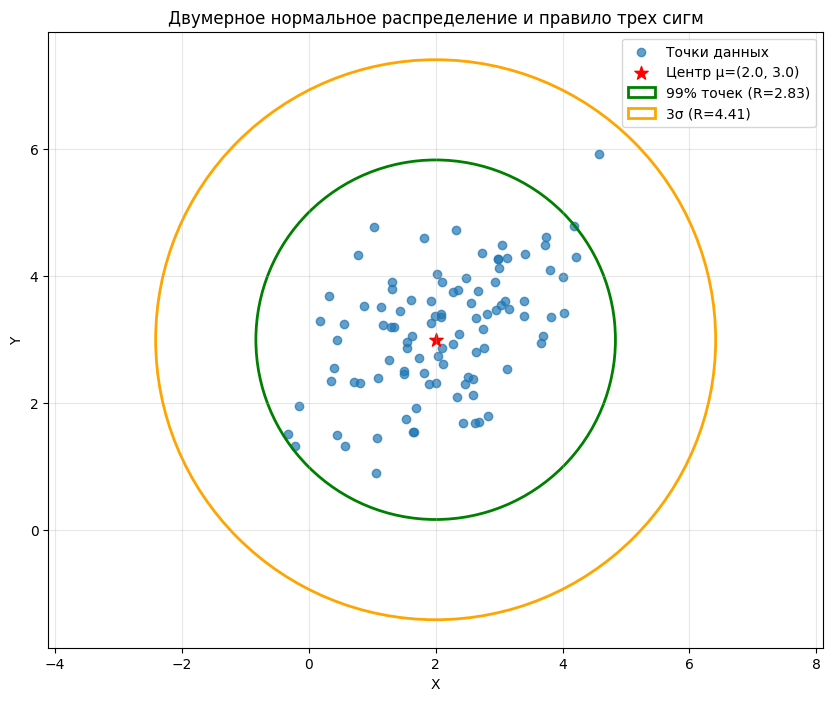

Всего точек: 100
Точек внутри окружности 3σ: 100 (100.0%)
Точек внутри 99% окружности: 99 (99.0%)
Радиус для 99% точек: 2.833
Радиус 3σ: 4.413


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Параметры распределения
np.random.seed(42)  # для воспроизводимости результатов
mu = np.array([2.0, 3.0])  # среднее значение
sigma = np.array([[1.5, 0.8], [0.8, 1.2]])  # ковариационная матрица

# Генерация 100 точек из двумерного нормального распределения
n_points = 100
points = np.random.multivariate_normal(mu, sigma, n_points)

# Вычисление расстояний от центра до точек
distances = np.linalg.norm(points - mu, axis=1)

# Находим радиус, содержащий 99% точек
radius_99 = np.percentile(distances, 99)

# Радиус 3 сигмы (для многомерного случая используем собственные значения)
eigenvals = np.linalg.eigvals(sigma)
sigma_3d = 3 * np.sqrt(np.max(eigenvals))  # консервативная оценка

# Визуализация
plt.figure(figsize=(10, 8))

# Точки данных
plt.scatter(points[:, 0], points[:, 1], alpha=0.7, label='Точки данных')

# Центр распределения
plt.scatter(mu[0], mu[1], color='red', s=100, marker='*', label=f'Центр μ=({mu[0]}, {mu[1]})')

# Окружность с 99% точек
circle_99 = plt.Circle(mu, radius_99, fill=False, color='green', linewidth=2, 
                       label=f'99% точек (R={radius_99:.2f})')
plt.gca().add_patch(circle_99)

# Окружность 3 сигмы
circle_3sigma = plt.Circle(mu, sigma_3d, fill=False, color='orange', linewidth=2, 
                          label=f'3σ (R={sigma_3d:.2f})')
plt.gca().add_patch(circle_3sigma)

# Настройки графика
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Двумерное нормальное распределение и правило трех сигм')
plt.legend()
plt.show()

# Статистика
points_inside_3sigma = np.sum(distances <= sigma_3d)
points_inside_99 = np.sum(distances <= radius_99)

print(f"Всего точек: {n_points}")
print(f"Точек внутри окружности 3σ: {points_inside_3sigma} ({points_inside_3sigma/n_points*100:.1f}%)")
print(f"Точек внутри 99% окружности: {points_inside_99} ({points_inside_99/n_points*100:.1f}%)")
print(f"Радиус для 99% точек: {radius_99:.3f}")
print(f"Радиус 3σ: {sigma_3d:.3f}")

## Задание №2

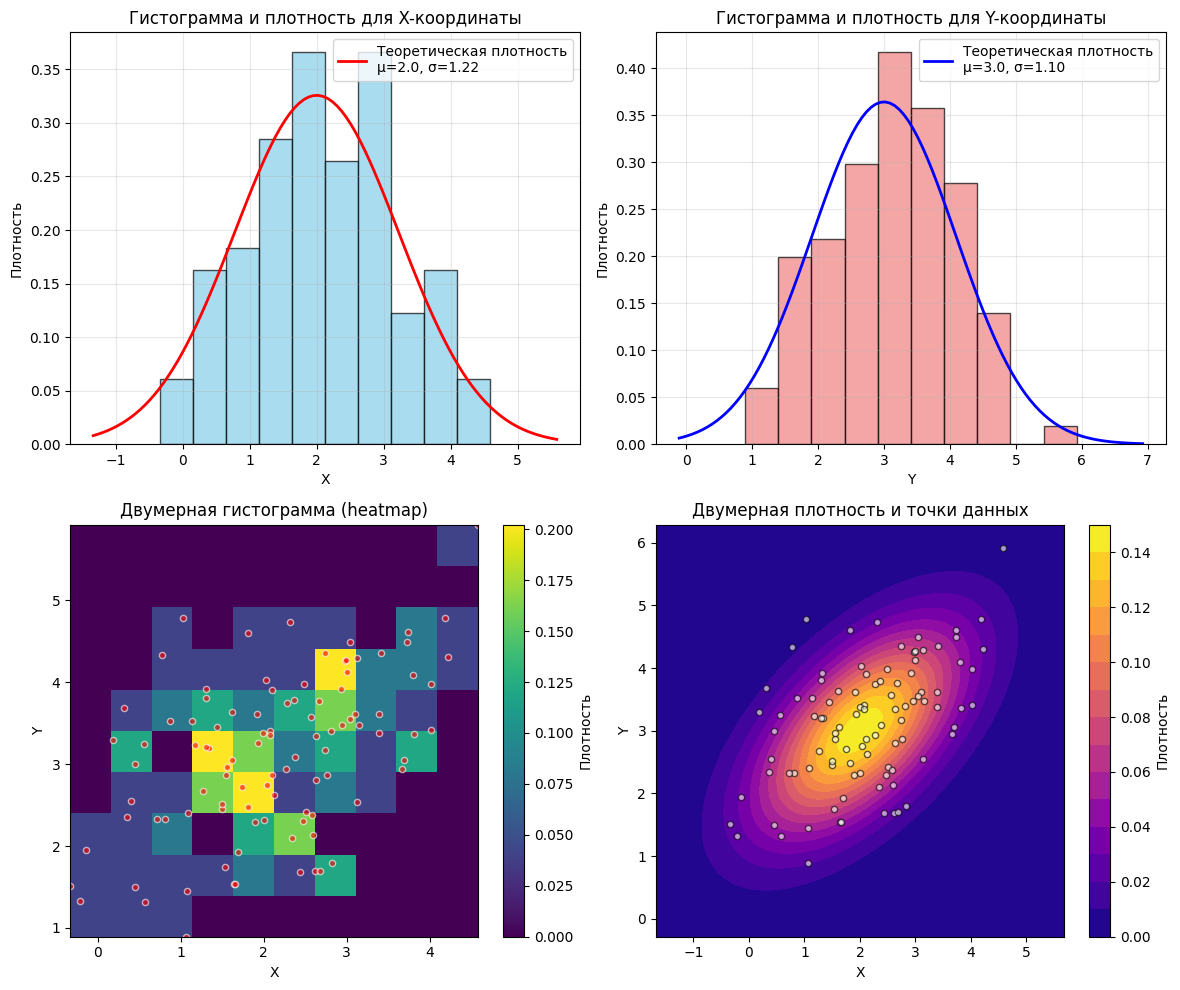

Статистика по координатам:
X: среднее = 2.115, std = 1.084 (теоретическое: 1.225)
Y: среднее = 3.128, std = 0.962 (теоретическое: 1.095)
Ковариация: выборочная = 0.511, теоретическая = 0.800


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

# Параметры распределения (те же, что в первом задании)
np.random.seed(42)
mu = np.array([2.0, 3.0])
sigma = np.array([[1.5, 0.8], [0.8, 1.2]])

# Генерация 100 точек из двумерного нормального распределения
n_points = 100
points = np.random.multivariate_normal(mu, sigma, n_points)

# Создание вспомогательного графика
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Гистограмма для X-координаты
x_data = points[:, 0]
axes[0, 0].hist(x_data, bins=10, density=True, alpha=0.7, color='skyblue', edgecolor='black')
x_range = np.linspace(x_data.min() - 1, x_data.max() + 1, 100)
x_pdf = norm.pdf(x_range, mu[0], np.sqrt(sigma[0, 0]))
axes[0, 0].plot(x_range, x_pdf, 'r-', linewidth=2, label=f'Теоретическая плотность\nμ={mu[0]:.1f}, σ={np.sqrt(sigma[0,0]):.2f}')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].set_title('Гистограмма и плотность для X-координаты')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Гистограмма для Y-координаты
y_data = points[:, 1]
axes[0, 1].hist(y_data, bins=10, density=True, alpha=0.7, color='lightcoral', edgecolor='black')
y_range = np.linspace(y_data.min() - 1, y_data.max() + 1, 100)
y_pdf = norm.pdf(y_range, mu[1], np.sqrt(sigma[1, 1]))
axes[0, 1].plot(y_range, y_pdf, 'b-', linewidth=2, label=f'Теоретическая плотность\nμ={mu[1]:.1f}, σ={np.sqrt(sigma[1,1]):.2f}')
axes[0, 1].set_xlabel('Y')
axes[0, 1].set_ylabel('Плотность')
axes[0, 1].set_title('Гистограмма и плотность для Y-координаты')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Двумерная гистограмма (heatmap)
hist, xedges, yedges = np.histogram2d(points[:, 0], points[:, 1], bins=10, density=True)
im = axes[1, 0].imshow(hist.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
                      origin='lower', cmap='viridis', aspect='auto')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
axes[1, 0].set_title('Двумерная гистограмма (heatmap)')
plt.colorbar(im, ax=axes[1, 0], label='Плотность')

# Добавляем точки поверх heatmap
axes[1, 0].scatter(points[:, 0], points[:, 1], alpha=0.6, color='red', s=20, edgecolors='white')

# Двумерная плотность с контурами
x = np.linspace(mu[0] - 3*np.sqrt(sigma[0,0]), mu[0] + 3*np.sqrt(sigma[0,0]), 100)
y = np.linspace(mu[1] - 3*np.sqrt(sigma[1,1]), mu[1] + 3*np.sqrt(sigma[1,1]), 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
rv = multivariate_normal(mu, sigma)
Z = rv.pdf(pos)

contour = axes[1, 1].contourf(X, Y, Z, levels=15, cmap='plasma')
axes[1, 1].scatter(points[:, 0], points[:, 1], alpha=0.6, color='white', s=20, edgecolors='black')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')
axes[1, 1].set_title('Двумерная плотность и точки данных')
plt.colorbar(contour, ax=axes[1, 1], label='Плотность')

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("Статистика по координатам:")
print(f"X: среднее = {x_data.mean():.3f}, std = {x_data.std():.3f} (теоретическое: {np.sqrt(sigma[0,0]):.3f})")
print(f"Y: среднее = {y_data.mean():.3f}, std = {y_data.std():.3f} (теоретическое: {np.sqrt(sigma[1,1]):.3f})")
print(f"Ковариация: выборочная = {np.cov(points.T)[0,1]:.3f}, теоретическая = {sigma[0,1]:.3f}")

## Задание №3

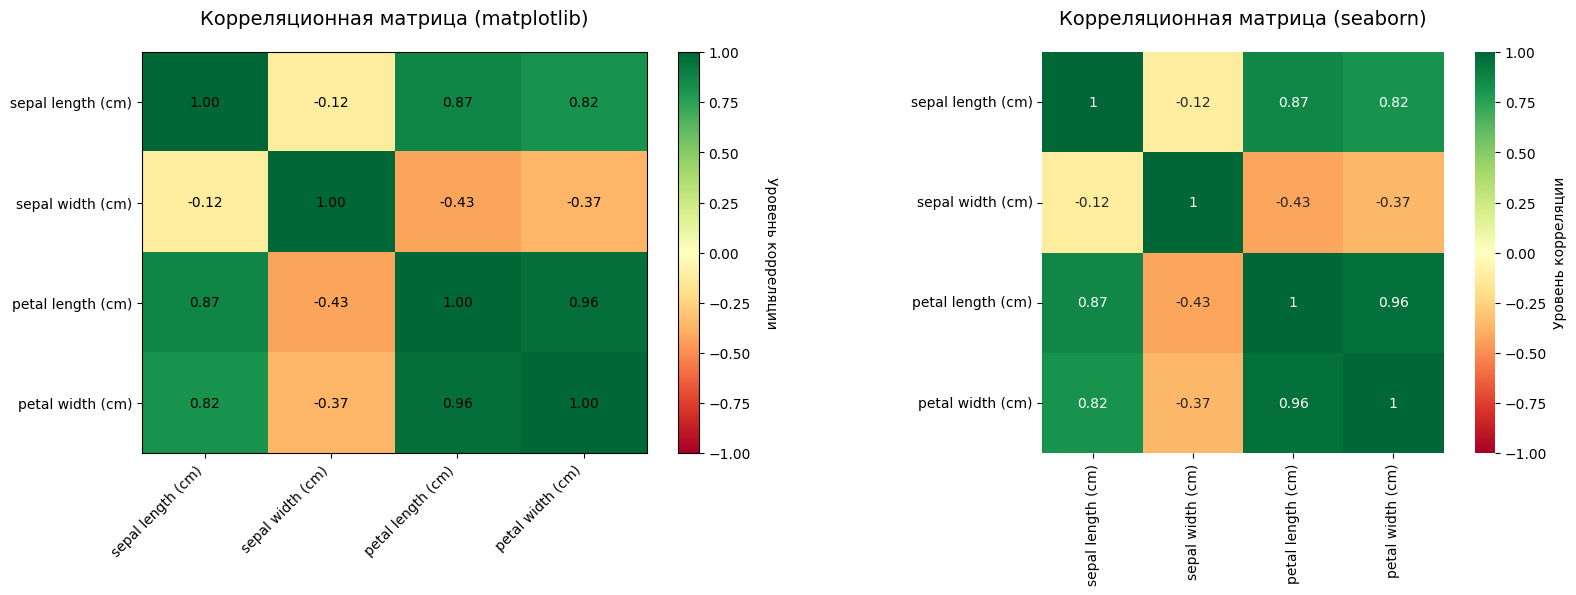

Корреляционная матрица:
[[ 1.         -0.11756978  0.87175378  0.81794113]
 [-0.11756978  1.         -0.4284401  -0.36612593]
 [ 0.87175378 -0.4284401   1.          0.96286543]
 [ 0.81794113 -0.36612593  0.96286543  1.        ]]

Интерпретация:
+1.00: полная прямая корреляция (зеленый)
 0.00: отсутствие корреляции (белый/желтый)
-1.00: полная обратная корреляция (красный)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Загрузка набора данных "Ирисы Фишера"
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Вычисление корреляционной матрицы
correlation_matrix = np.corrcoef(X.T)

# Создание графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График 1: с использованием matplotlib
im = ax1.imshow(correlation_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax1.set_xticks(np.arange(len(feature_names)))
ax1.set_yticks(np.arange(len(feature_names)))
ax1.set_xticklabels(feature_names, rotation=45, ha='right')
ax1.set_yticklabels(feature_names)
ax1.set_title('Корреляционная матрица (matplotlib)', fontsize=14, pad=20)

# Добавление значений корреляции на тепловую карту
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        text = ax1.text(j, i, f'{correlation_matrix[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10)

# Добавление цветовой шкалы
cbar = plt.colorbar(im, ax=ax1)
cbar.set_label('Уровень корреляции', rotation=270, labelpad=20)

# График 2: с использованием seaborn
sns.heatmap(correlation_matrix, 
            xticklabels=feature_names, 
            yticklabels=feature_names,
            annot=True,  # Добавляем значения в ячейки
            cmap='RdYlGn',
            vmin=-1, vmax=1,
            center=0,
            square=True,
            cbar_kws={'label': 'Уровень корреляции'},
            ax=ax2)
ax2.set_title('Корреляционная матрица (seaborn)', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

# Дополнительная информация о корреляциях
print("Корреляционная матрица:")
print(correlation_matrix)
print("\nИнтерпретация:")
print("+1.00: полная прямая корреляция (зеленый)")
print(" 0.00: отсутствие корреляции (белый/желтый)")
print("-1.00: полная обратная корреляция (красный)")

## Задание №4

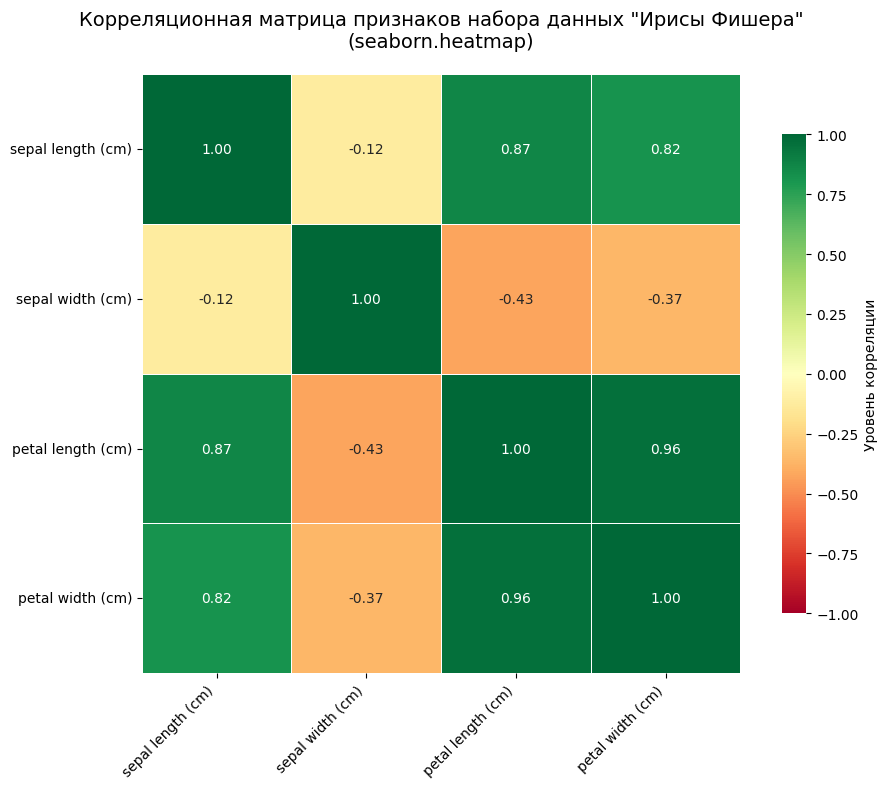

Корреляционная матрица:
sepal length (cm) - sepal length (cm): 1.000
sepal length (cm) - sepal width (cm): -0.118
sepal length (cm) - petal length (cm): 0.872
sepal length (cm) - petal width (cm): 0.818
sepal width (cm) - sepal width (cm): 1.000
sepal width (cm) - petal length (cm): -0.428
sepal width (cm) - petal width (cm): -0.366
petal length (cm) - petal length (cm): 1.000
petal length (cm) - petal width (cm): 0.963
petal width (cm) - petal width (cm): 1.000


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris

# Загрузка набора данных "Ирисы Фишера"
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Вычисление корреляционной матрицы
correlation_matrix = np.corrcoef(X.T)

# Создание тепловой карты с использованием seaborn
plt.figure(figsize=(10, 8))

# Создание тепловой карты с seaborn.heatmap
heatmap = sns.heatmap(correlation_matrix,
                      xticklabels=feature_names,
                      yticklabels=feature_names,
                      annot=True,  # Добавляем числовые значения в ячейки
                      fmt='.2f',   # Формат чисел: 2 знака после запятой
                      cmap='RdYlGn',  # Цветовая схема: красный-желтый-зеленый
                      vmin=-1,     # Минимальное значение для цветовой шкалы
                      vmax=1,      # Максимальное значение для цветовой шкалы
                      center=0,    # Центр цветовой шкалы на 0
                      square=True, # Квадратные ячейки
                      cbar_kws={'label': 'Уровень корреляции', 'shrink': 0.8},
                      linewidths=0.5,  # Тонкие линии между ячейками
                      linecolor='white')  # Белые линии между ячейками

# Настройка внешнего вида
plt.title('Корреляционная матрица признаков набора данных "Ирисы Фишера"\n(seaborn.heatmap)', 
          fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')  # Наклон подписей по X для лучшей читаемости
plt.yticks(rotation=0)               # Горизонтальные подписи по Y

# Улучшаем читаемость
plt.tight_layout()
plt.show()

# Дополнительная информация
print("Корреляционная матрица:")
for i, feature1 in enumerate(feature_names):
    for j, feature2 in enumerate(feature_names):
        if i <= j:  # Выводим только уникальные пары (верхний треугольник)
            corr_value = correlation_matrix[i, j]
            print(f"{feature1} - {feature2}: {corr_value:.3f}")